In [27]:
from typing import Dict, List, Any, Tuple
from numpy.typing import NDArray

from model_ranking import (
    get_summary_results, 
    per_source_model_results,
    cmb_consistency_score_weighted_average,
    correlation_table,
    to_target_transfer_correlations_with_norm,
    per_target_consis_result_type,
    per_target_performance_result_type,
)
from model_ranking import plot_alpha_sweep_specific_norm

In [28]:
Unet_source_models={
    "BBBC039": "BC_model4",
    "Go-Nuclear": "GN_model4",
    "HeLaNuc": "HN_model1",
    "Hoechst": "Hst_model5",
    "S_BIAD895": "895_model2",
    "S_BIAD1196": "1196_model3",
    "S_BIAD1410": "1410_model2",
}

result_folders={
    "BBBC039": "P_1",
    "DSB2018": "P_2",
    "Go-Nuclear": "P_1",
    "HeLaNuc": "P_1",
    "Hoechst": "P_1",
    "S_BIAD895": "P_1",
    "S_BIAD1196": "P_1",
    "S_BIAD1410": "P_1",
}

per_target_norms: Dict[str, List[Tuple[float, float]]] = {
    "BBBC039": [(5.0, 98.0)],
    "DSB2018": [(5.0, 98.0)],
    "Go-Nuclear": [(0.0, 99.8)],
    "HeLaNuc": [(5.0, 99.6)],
    "Hoechst": [(5.0, 98.0)],
    "S_BIAD634": [(5.0, 98.0)],
    "S_BIAD895": [(5.0, 98.0)],
    "S_BIAD1196": [(5.0, 98.0)],
    "S_BIAD1410": [(5.0, 98.0)],
}

perf_key = "hard_f1"
approach="consistency"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei"

In [29]:
summary_results_postfix = ""
selected_augmentations = {
    "none": [""],
    #"gauss": ["a0-005", "a005-01", "a01-02"],
    "gauss": ["a003-005", "a005-007", "a007-01", "a01-012", "a012-015", "a015-02", "a02-025", "a025-03"],
}
targets = [
    "BBBC039",
    "DSB2018", 
    #"Go-Nuclear", 
    #"HeLaNuc", 
    "Hoechst", 
    "S_BIAD895", 
    #"S_BIAD1196", 
    #"S_BIAD1410"
]
source_model_types = [Unet_source_models]

# Foreground Consistency

In [30]:
# consis_keys={
#     "BBBC039": "HD_th05",
#     "DSB2018": "HD_th05",
#     "Go-Nuclear": "HD_th05",
#     "HeLaNuc": "HD_th05",
#     "Hoechst": "HD_th05",
#     "S_BIAD895": "HD_th05",
#     "S_BIAD1196": "HD_th05",
#     "S_BIAD1410": "HD_th05",
# }
consis_keys={
    "BBBC039": "NHD_consis",
    "DSB2018": "NHD_consis",
    "Hoechst": "NHD_consis",
    "S_BIAD895": "NHD_consis",
}

In [31]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:
        sources = list(model_type.keys())
        if ((target == "HeLaNuc") and ("HeLaNuc" in sources)):
            sources.remove("HeLaNuc")
        if ((target == "S_BIAD895") and ("S_BIAD895" in sources)):
            sources.remove("S_BIAD895")
        if ((target == "S_BIAD1196") and ("S_BIAD1196" in sources)):
            sources.remove("S_BIAD1196")
        if ((target == "S_BIAD1410") and ("S_BIAD1410" in sources)):
            sources.remove("S_BIAD1410")
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            # selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            #consis_postfix="median_per_alpha",
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: BBBC039


100%|██████████| 1/1 [00:00<00:00, 21.00it/s]


Source: Go-Nuclear


100%|██████████| 1/1 [00:00<00:00, 20.25it/s]


Source: HeLaNuc


...

100%|██████████| 1/1 [00:00<00:00, 19.86it/s]


Source: S_BIAD1196


100%|██████████| 1/1 [00:00<00:00, 20.68it/s]


Source: S_BIAD1410


100%|██████████| 1/1 [00:00<00:00, 21.37it/s]


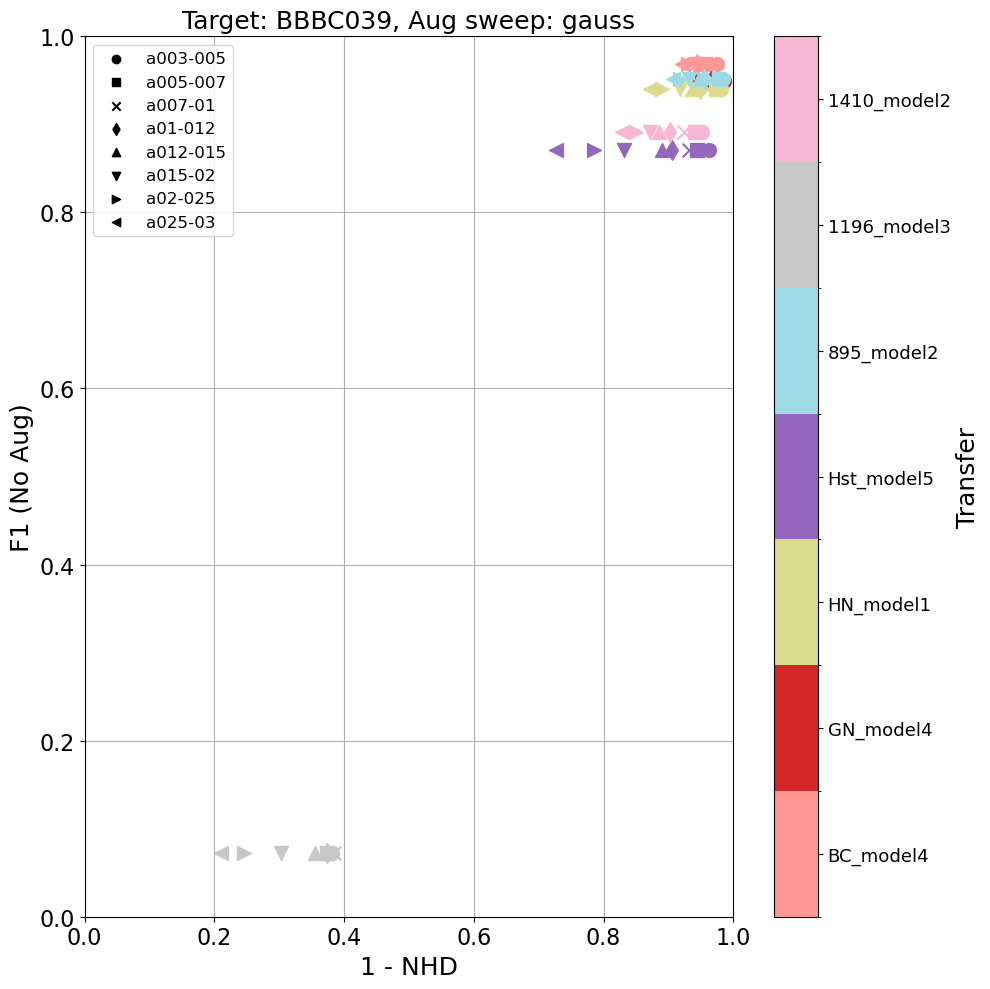

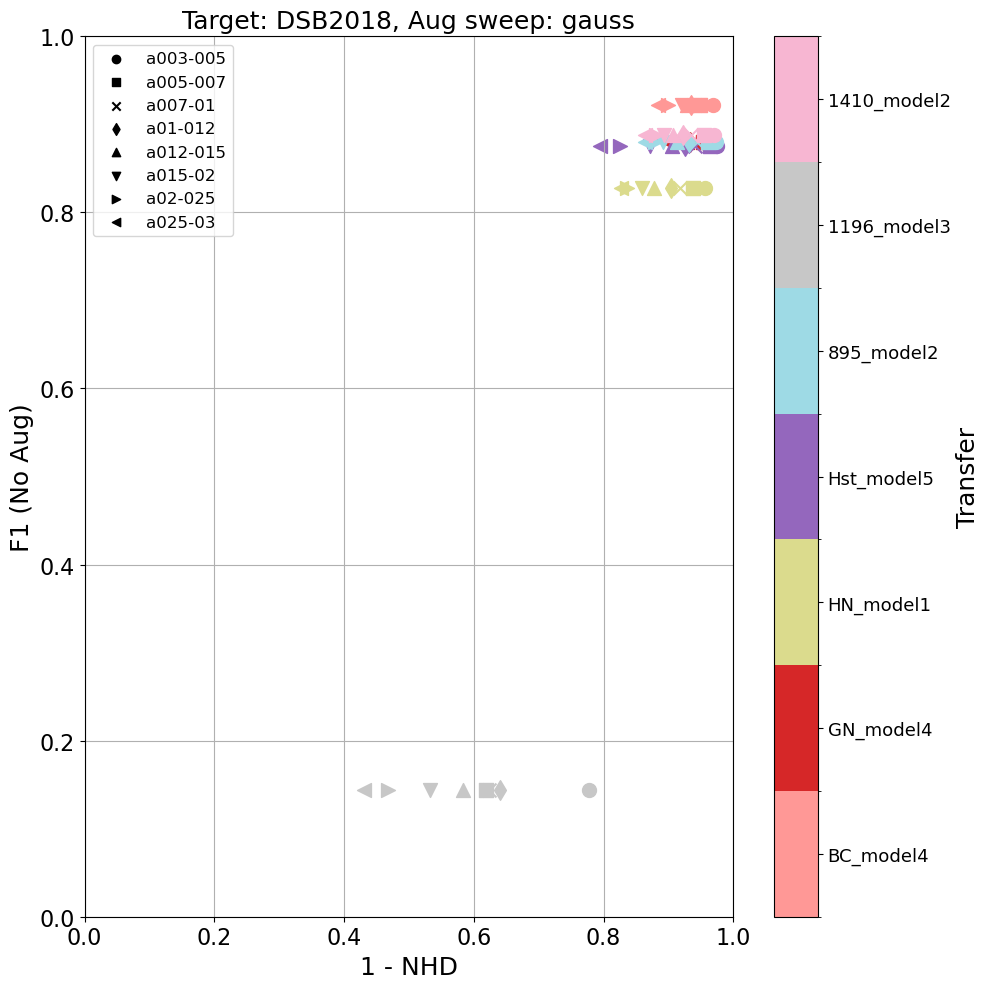

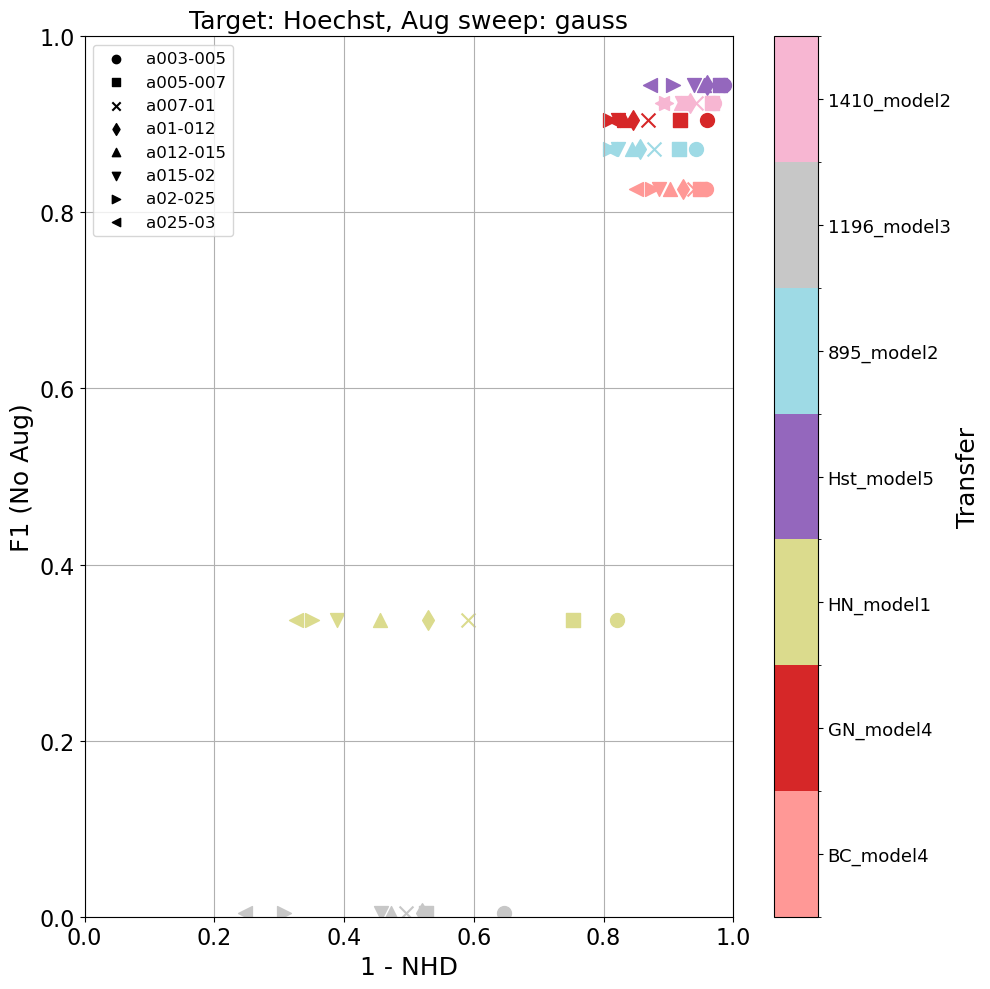

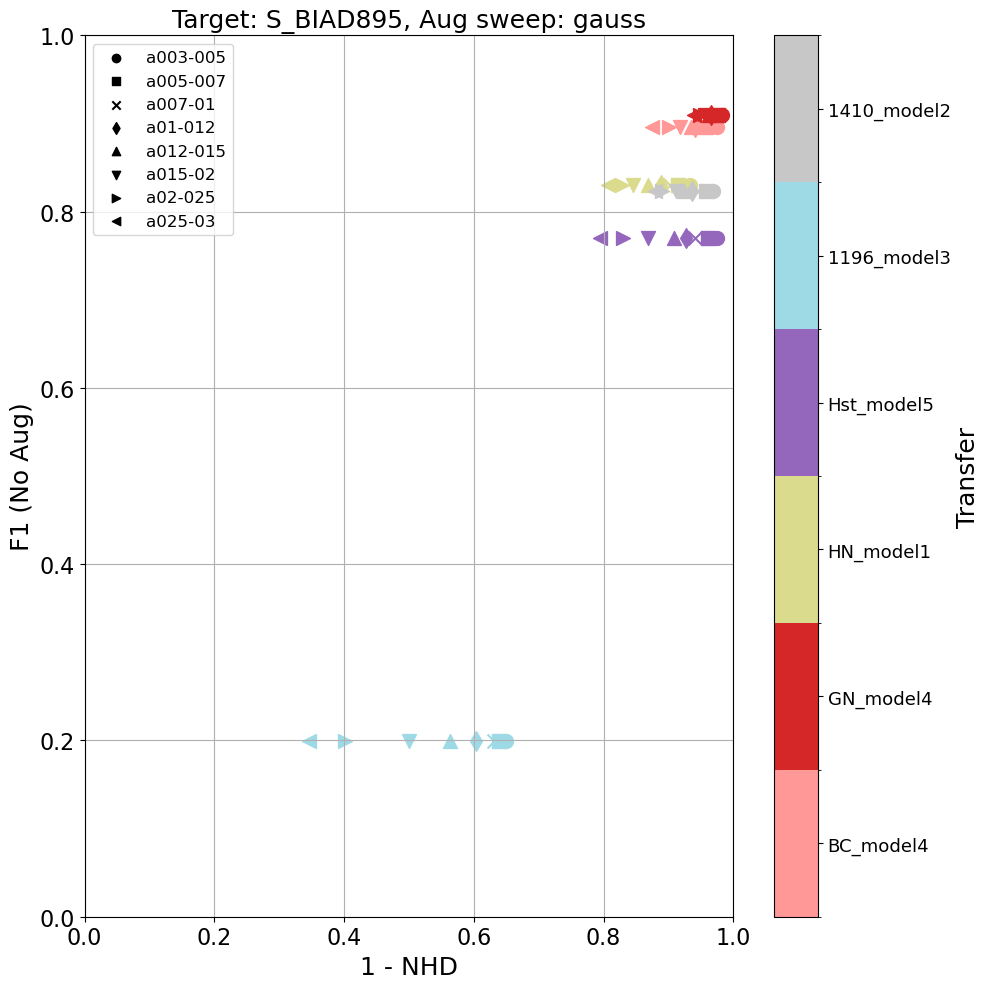

In [32]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="1 - NHD",
        invert_consis_metric= True,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

In [33]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_forg_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
    perturbation_key="gauss",
    invert_consis_score= True,
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

gauss: a003-005
                  kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                   
Mito BBBC039    0.52     0.14   0.71        0.08  1.00      0.0
     DSB2018    0.24     0.49   0.39        0.39  1.00      0.0
     Hoechst    0.90     0.01   0.96        0.01  0.98      0.0
     S_BIAD895  0.47     0.29   0.60        0.26  0.98      0.0
gauss: a005-007
                  kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                   
Mito BBBC039    0.62     0.06   0.75        0.08  1.00      0.0
     DSB2018    0.14     0.79   0.32        0.47  1.00      0.0
     Hoechst    0.81     0.02   0.89        0.01  0.98      0.0
     S_BIAD895  0.33     0.47   0.49        0.38  0.98      0.0
gauss: a007-01
                  kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                   
Mito BBBC039    0.52     0.15   0.71        0.08  1.00   

# Save results

In [34]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_50_980']
        else:
            per_target_performance[target][model] = performance

In [35]:
import json
import os
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/transfer_results/consistency/NHD_consistency/FORG_expanded_augs"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for i, alpha in enumerate(selected_augmentations['gauss']):
    per_target_consistency: Dict[str, Dict[str,float]] = {}
    for target, per_model_consistency in per_target_forg_consistency.items():
        per_target_consistency[target] = {}
        for model, consistency in per_model_consistency.items():
            per_target_consistency[target][model] = consistency['norm_50_980']['gauss'][i]

    with open(os.path.join(save_path, f"transfer_Gauss_{alpha}_Forg_NHD_scores.json"), "w") as f:
        results: Dict[str, Any] = {
            "transfer_scores": convert_numpy_types(per_target_consistency),
        }
        json.dump(results, f, indent=4)

In [ ]:
save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/transfer_results/consistency/EI_consistency"
if not os.path.exists(save_path):
    os.makedirs(save_path)
# with open(os.path.join(save_path, f"transfer_performance_ARE_scores_with_NORM.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "performance_scores": convert_numpy_types(per_target_forg_performance),
#     }
#     json.dump(results, f, indent=4)

# Background Consistency

In [36]:
consis_keys_bckg = {
    "BBBC039": "NHD_consis_bckg",
    "DSB2018": "NHD_consis_bckg",
    "Hoechst": "NHD_consis_bckg",
    "S_BIAD895": "NHD_consis_bckg",
}

In [37]:
per_target_bckg_consistency: Dict[str, Dict[str, Dict[str, Dict[str, NDArray[Any]]]]] = {}
per_target_bckg_performance: Dict[str, Dict[str, Dict[str, NDArray[Any]]]] = {}

for i, target in enumerate(targets):
    per_source_bckg_consistency = {}
    per_source_bckg_performance = {}

    for model_type in source_model_types:
        sources = list(model_type.keys())
        if ((target == "HeLaNuc") and ("HeLaNuc" in sources)):
            sources.remove("HeLaNuc")
        if ((target == "S_BIAD895") and ("S_BIAD895" in sources)):
            sources.remove("S_BIAD895")
        if ((target == "S_BIAD1196") and ("S_BIAD1196" in sources)):
            sources.remove("S_BIAD1196")
        if ((target == "S_BIAD1410") and ("S_BIAD1410" in sources)):
            sources.remove("S_BIAD1410")

        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys_bckg,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_bckg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_bckg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
        
    
    per_target_bckg_consistency[target] = per_source_bckg_consistency
    per_target_bckg_performance[target] = per_source_bckg_performance

    

Source: BBBC039


100%|██████████| 1/1 [00:00<00:00, 19.30it/s]


Source: Go-Nuclear


100%|██████████| 1/1 [00:00<00:00, 20.16it/s]


Source: HeLaNuc


...

100%|██████████| 1/1 [00:00<00:00, 23.71it/s]


Source: S_BIAD1196


100%|██████████| 1/1 [00:00<00:00, 25.18it/s]


Source: S_BIAD1410


100%|██████████| 1/1 [00:00<00:00, 24.43it/s]


In [38]:
per_target_cmb_consistency = cmb_consistency_score_weighted_average(
    per_target_forg_consistency,
    per_target_bckg_consistency,
    w_fg=0.5,
    w_bg=0.5,
    perturbation_key="gauss",
    norm_key="norm_50_980",
)

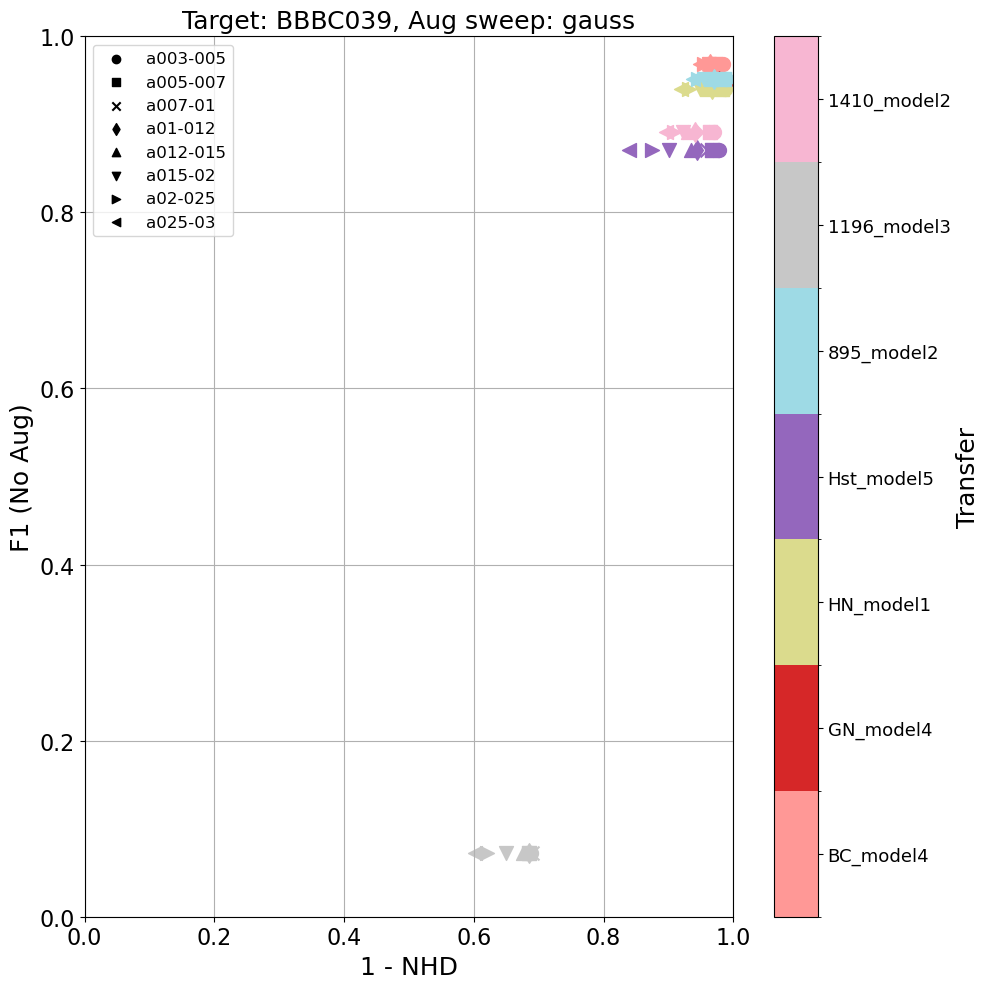

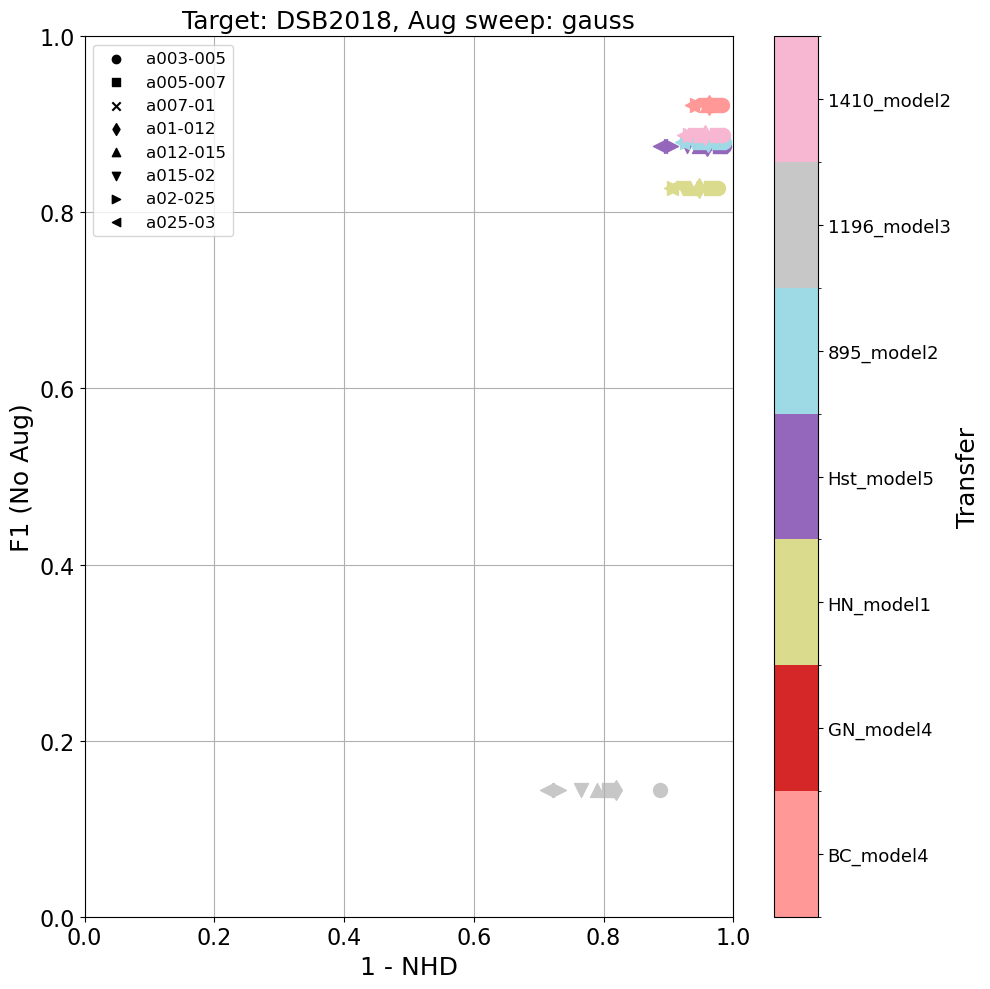

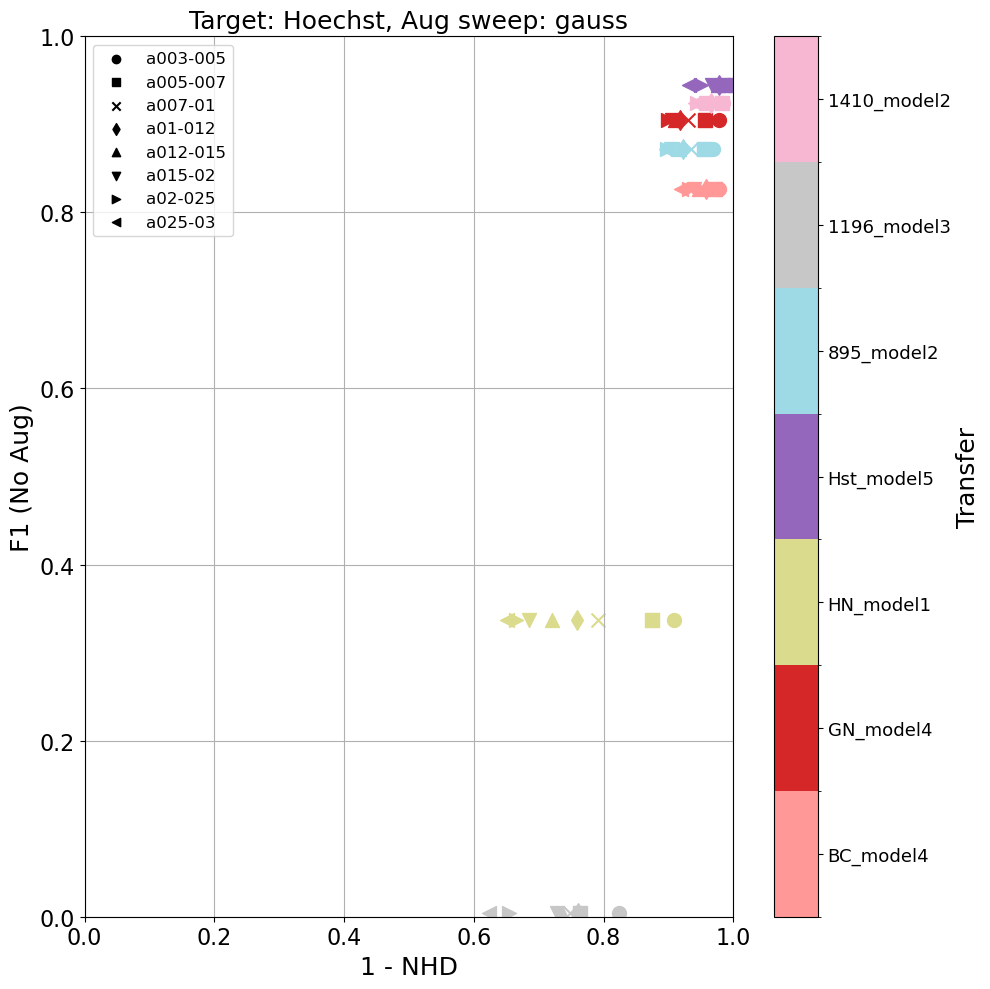

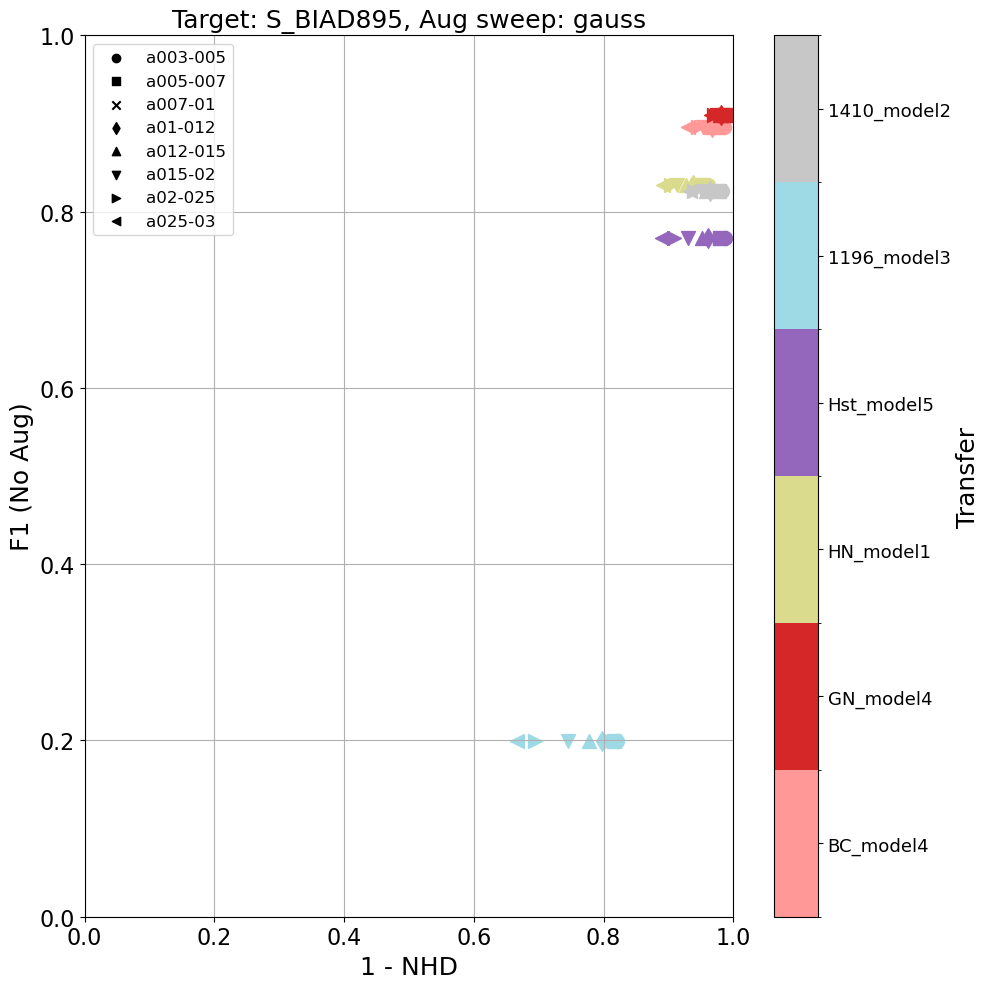

In [39]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="1 - NHD",
        invert_consis_metric= True,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

In [40]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_cmb_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
    perturbation_key="gauss",
    invert_consis_score= True,
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

gauss: a003-005
                  kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                   
Mito BBBC039    0.52     0.13   0.71        0.09  1.00      0.0
     DSB2018    0.24     0.58   0.39        0.38  1.00      0.0
     Hoechst    0.90     0.00   0.96        0.00  0.98      0.0
     S_BIAD895  0.47     0.28   0.60        0.26  0.98      0.0
gauss: a005-007
                  kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                   
Mito BBBC039    0.62     0.07   0.75        0.06  1.00      0.0
     DSB2018    0.14     0.74   0.32        0.50  1.00      0.0
     Hoechst    0.81     0.01   0.89        0.02  0.98      0.0
     S_BIAD895  0.33     0.46   0.49        0.37  0.98      0.0
gauss: a007-01
                  kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                   
Mito BBBC039    0.52     0.13   0.71        0.09  1.00   

# Save Results

In [41]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_50_980']
        else:
            per_target_performance[target][model] = performance


In [42]:
import json
import os
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/transfer_results/consistency/NHD_consistency/CMB_expanded_augs"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for i, alpha in enumerate(selected_augmentations['gauss']):
    per_target_consistency: Dict[str, Dict[str,float]] = {}
    for target, per_model_consistency in per_target_cmb_consistency.items():
        per_target_consistency[target] = {}
        for model, consistency in per_model_consistency.items():
            per_target_consistency[target][model] = consistency['norm_50_980']['gauss'][i]

    with open(os.path.join(save_path, f"transfer_Gauss_{alpha}_CMB_05f_05b_NHD_scores.json"), "w") as f:
        results: Dict[str, Any] = {
            "transfer_scores": convert_numpy_types(per_target_consistency),
        }
        json.dump(results, f, indent=4)